In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
import tensorflow as tf
from keras import Model
from keras.layers import Conv1D, Dense, Dropout, BatchNormalization, Flatten, Input, Activation, Add
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


2025-10-03 11:57:04.344807: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print(tf.test.is_built_with_cuda())
print(tf.config.list_physical_devices('GPU'))

True
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
data = pd.read_csv('..//data//NSW//processed//nsw_demand_features.csv')

In [19]:
#For the test data we need the x values from 2018 12 31
test_data = data[data['timestamp'] >= '2018-12-31 00:00:00+00:00']
data = data[data['timestamp'] < '2019-01-01 00:00:00+00:00']

In [20]:
data = data.dropna()
data_time = data
data = data.drop(columns=['timestamp', 'y_forecast','is_hot_slot', 'is_cold_slot', 'is_hot_day',
        'is_cold_day', 'is_normal_day','date'])
#data = data.drop(columns=['timestamp', 'y_forecast','date'])
data.head(10)

,temp,y,hour,dow,is_weekend,sin_hh,cos_hh,sin_dow,cos_dow,is_holiday,...,y_lag336,y_roll_mean_48,y_roll_std_48,y_roll_mean_336,temp_lag1,temp_lag2,temp_lag3,temp_lag48,temp_roll_max_48,temp_roll_min_48
336,21.80,7688.54,0.0,4,0,0.000000,1.000000,-0.433884,-0.900969,0,...,8038.00,8566.847500,1160.023377,8268.116429,21.90,21.80,21.60,20.5,23.6,20.5
337,21.15,7498.35,0.5,4,0,0.130526,0.991445,-0.433884,-0.900969,0,...,7809.31,8567.117917,1159.812679,8267.076369,21.80,21.90,21.80,20.7,23.6,20.5
338,21.40,7242.52,1.0,4,0,0.258819,0.965926,-0.433884,-0.900969,0,...,7483.69,8568.469792,1158.500251,8266.150893,21.15,21.80,21.90,20.8,23.6,20.5
339,21.50,6972.24,1.5,4,0,0.382683,0.923880,-0.433884,-0.900969,0,...,7117.23,8569.016042,1157.855120,8265.433125,21.40,21.15,21.80,20.5,23.6,20.5
340,21.60,6706.22,2.0,4,0,0.500000,0.866025,-0.433884,-0.900969,0,...,6812.03,8569.677708,1156.913369,8265.001607,21.50,21.40,21.15,20.6,23.6,20.6
341,21.70,6525.71,2.5,4,0,0.608761,0.793353,-0.433884,-0.900969,0,...,6544.33,8569.956875,1156.452366,8264.686696,21.60,21.50,21.40,21.0,23.6,20.6
342,21.50,6492.12,3.0,4,0,0.707107,0.707107,-0.433884,-0.900969,0,...,6377.32,8570.960000,1154.618200,8264.631280,21.70,21.60,21.50,21.0,23.6,20.6
343,20.80,6429.62,3.5,4,0,0.793353,0.608761,-0.433884,-0.900969,0,...,6282.85,8571.788750,1153.078414,8264.972946,21.50,21.70,21.60,21.0,23.6,20.6
344,19.90,6521.71,4.0,4,0,0.866025,0.500000,-0.433884,-0.900969,0,...,6211.49,8572.073542,1152.536188,8265.409762,20.80,21.50,21.70,20.7,23.6,20.6
345,19.70,6691.55,4.5,4,0,0.923880,0.382683,-0.433884,-0.900969,0,...,6248.31,8572.770625,1151.258433,8266.333036,19.90,20.80,21.50,20.6,23.6,19.9


In [21]:
scaler = MinMaxScaler()
scaler.fit(data)
data = pd.DataFrame(scaler.transform(data), columns=data.columns)
data.head(5)


,temp,y,hour,dow,is_weekend,sin_hh,cos_hh,sin_dow,cos_dow,is_holiday,...,y_lag336,y_roll_mean_48,y_roll_std_48,y_roll_mean_336,temp_lag1,temp_lag2,temp_lag3,temp_lag48,temp_roll_max_48,temp_roll_min_48
0,0.510497,0.274997,0.000000,0.666667,0.0,0.500000,1.000000,0.277479,0.0,0.0,...,0.311762,0.444481,0.333878,0.378885,0.512707,0.510497,0.506077,0.481768,0.368992,0.781362
1,0.496133,0.254988,0.021277,0.666667,0.0,0.565263,0.995722,0.277479,0.0,0.0,...,0.287703,0.444529,0.333787,0.378639,0.510497,0.512707,0.510497,0.486188,0.368992,0.781362
2,0.501657,0.228073,0.042553,0.666667,0.0,0.629410,0.982963,0.277479,0.0,0.0,...,0.253446,0.444767,0.333221,0.378421,0.496133,0.510497,0.512707,0.488398,0.368992,0.781362
3,0.503867,0.199639,0.063830,0.666667,0.0,0.691342,0.961940,0.277479,0.0,0.0,...,0.214892,0.444864,0.332942,0.378252,0.501657,0.496133,0.510497,0.481768,0.368992,0.781362
4,0.506077,0.171652,0.085106,0.666667,0.0,0.750000,0.933013,0.277479,0.0,0.0,...,0.182784,0.444980,0.332536,0.378150,0.503867,0.501657,0.496133,0.483978,0.368992,0.784946


In [7]:
print(scaler.data_min_[1])
print(scaler.data_max_[1])

5074.63
14579.86


In [8]:

#Format the data to get the previous 48 x values with the next 48 y values for prediction
def format_data(data):
    x_data = np.array(data.drop(columns=['y']))
    y_data = np.array(data['y'])
    X, y = [], []
    for i in range(len(data) + 1 - 48*2):
        X.append(x_data[i:(i + 48)])
        y.append(y_data[i + 48:i + 48*2])
    return np.array(X), np.array(y)

#Format input and output data
X, y = format_data(data)

#Test size of 0.11104 splits the data at 2018-01-01 00:00:00+00:00 for validation requirements
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.11104, shuffle=False)
print(X_train.shape)
print(X_test.shape)

(139873, 48, 22)
(17472, 48, 22)


In [ ]:
#Format the data to get the previous 48 x trying to predict just the single value 24 hours ahead
def format_data(data):
    x_data = np.array(data.drop(columns=['y']))
    y_data = np.array(data['y'])
    X, y = [], []
    for i in range(len(data) + 1 - 48*2):
        X.append(x_data[i:(i + 48)])
        y.append(y_data[i + 48:i + 48*2])
    return np.array(X), np.array(y)

#Format input and output data
X, y = format_data(data)

#Try just predicting 24 hours ahead
y1 = []
for a in y:
    y1.append(a[-1])


y = np.array(y1).reshape(157345,1)

#Test size of 0.11104 splits the data at 2018-01-01 00:00:00+00:00 for validation requirements
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.11104, shuffle=False)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(139873, 48, 22)
(17472, 48, 22)
(139873, 1)
(17472, 1)


In [22]:
# Get the values day by day only i.e. midnight to 1130 pm for x to predict midnight to 1130pm for y
def format_data_time(data, test):
    x_data = np.array(data.drop(columns=['y']))
    y_data = np.array(data['y'])
    time_data = np.array(test['timestamp'])
    X, y = [], []
    for i in range(len(data) - 48*2):
        X.append(x_data[i:(i + 48)])
        y.append(y_data[i + 48:i + 48*2])
    return pd.DataFrame({'time': time_data[:-96], 'X': X, 'y': y})

data_time = format_data_time(data, data_time)

data_time['datetime'] = pd.to_datetime(data_time['time'])

data_day = data_time.set_index('datetime').between_time('23:59', '00:01').reset_index()

x_format = []
for a in data_day['X'].values:
    x_format.append(list(a))

y_format = []
for a in data_day['y'].values:
    y_format.append(list(a))
    

X = np.array(x_format)
y = np.array(y_format)


#Test size of 0.11104 splits the data at 2018-01-01 00:00:00+00:00 for validation requirements
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.11104, shuffle=False)
print(X_train.shape)
print(X_test.shape)

(2914, 48, 22)
(364, 48, 22)


In [23]:
def residual_block(input, filters, d):
    input = Input(shape=(None, input))
    x = Conv1D(filters, 5, dilation_rate = d, padding='causal')(input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)
    x = Conv1D(filters, 5, dilation_rate = d, padding='causal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)    

    skip = input
    if input_features != filters:
        skip = Conv1D(filters, kernel_size = 1, padding='same')(skip)
        
    out = Add()([skip, x])
    out = Activation('relu')(out)
    
    return Model(input, out)


#input_features = 27
input_features = 22

model = Sequential()
model.add(Input(shape=(48,input_features)))

for i in range(1,6):
    filters = 32 * (2**(i-1))
    block = residual_block(input_features, filters, d=(2**i))
    model.add(block)
    input_features = filters
    
model.add(Conv1D(filters=1, kernel_size=1, padding='causal'))


model.compile(optimizer='adam', loss='mse', metrics=['mae'])

#Early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

I0000 00:00:1759456989.114189   47023 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 48, 32)         │         9,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_2 (Functional)       │ (None, 48, 64)         │        33,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_4 (Functional)       │ (None, 48, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_6 (Functional)       │ (None, 48, 256)        │       527,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_8 (Functional)       │ (None, 48, 512)        │     2,102,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 48, 1)          │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,806,049 (10.70 MB)

 Trainable params: 2,802,081 (10.69 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [25]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=[early_stopping,reduce_lr])

Epoch 1/100


2025-10-03 12:03:36.772128: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ad4cc02c720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-03 12:03:36.772159: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-10-03 12:03:37.002955: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-03 12:03:38.213699: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


 1/92 ━━━━━━━━━━━━━━━━━━━━ 37:48 25s/step - loss: 1.4297 - mae: 0.9061

I0000 00:00:1759457034.782815   48234 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 186ms/step - loss: 0.9210 - mae: 0.5175 - val_loss: 0.1297 - val_mae: 0.3398 - learning_rate: 0.0010
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1042 - mae: 0.2478 - val_loss: 0.0459 - val_mae: 0.1878 - learning_rate: 0.0010
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0723 - mae: 0.2085 - val_loss: 0.0296 - val_mae: 0.1480 - learning_rate: 0.0010
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0490 - mae: 0.1725 - val_loss: 0.0105 - val_mae: 0.0831 - learning_rate: 0.0010
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0345 - mae: 0.1453 - val_loss: 0.0087 - val_mae: 0.0743 - learning_rate: 0.0010
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0255 - mae: 0.1249 - val_loss: 0.0126 - val_mae: 0.0915 - learning_rate: 0.0010
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0196 - mae: 0.1092 - val_loss: 0.0090 - val_mae: 0.0747 - learning_rate: 0.0010
Epoch 8/100
92/9

In [26]:
#save test data for different formatting to allow for visualisation
test_data_visual = test_data
#Format test data
test_data = test_data.dropna()
test_data = test_data.drop(columns=['timestamp', 'y_forecast','is_hot_slot', 'is_cold_slot', 'is_hot_day','is_cold_day', 'is_normal_day','date'])
#test_data = test_data.drop(columns=['timestamp', 'y_forecast','date'])
test_data = pd.DataFrame(scaler.transform(test_data), columns=data.columns)
test_data.head()

,temp,y,hour,dow,is_weekend,sin_hh,cos_hh,sin_dow,cos_dow,is_holiday,...,y_lag336,y_roll_mean_48,y_roll_std_48,y_roll_mean_336,temp_lag1,temp_lag2,temp_lag3,temp_lag48,temp_roll_max_48,temp_roll_min_48
0,0.534807,0.256320,0.000000,0.0,0.0,0.500000,1.000000,0.5,1.0,0.0,...,0.163019,0.411603,0.434926,0.294898,0.532597,0.537017,0.543646,0.501657,0.734884,0.734767
1,0.514917,0.232042,0.021277,0.0,0.0,0.565263,0.995722,0.5,1.0,0.0,...,0.146369,0.411420,0.435203,0.295521,0.534807,0.532597,0.537017,0.497238,0.734884,0.734767
2,0.508287,0.216583,0.042553,0.0,0.0,0.629410,0.982963,0.5,1.0,0.0,...,0.135982,0.411192,0.435639,0.296093,0.514917,0.534807,0.532597,0.492818,0.734884,0.734767
3,0.506077,0.188404,0.063830,0.0,0.0,0.691342,0.961940,0.5,1.0,0.0,...,0.110015,0.411113,0.435814,0.296631,0.508287,0.514917,0.534807,0.495028,0.734884,0.734767
4,0.492818,0.170891,0.085106,0.0,0.0,0.750000,0.933013,0.5,1.0,0.0,...,0.093222,0.411120,0.435794,0.297154,0.506077,0.508287,0.514917,0.492818,0.734884,0.734767


In [27]:
from tensorflow.keras.models import load_model
modelAll = load_model("TCNModel.keras")

In [11]:
X_test, y_test = format_data(test_data)

# y1_test = []
# for a in y_test:
#     y1_test.append(a[-1])


# y_test = np.array(y1_test).reshape(y_test.shape[0],1)


test_loss = model.evaluate(X_test, y_test)
print(f'Test Loss (MSE) and (MAE): {test_loss}')

2025-10-03 11:46:10.747940: I external/local_xla/xla/service/service.cc:163] XLA service 0x73a878006d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-03 11:46:10.748004: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-10-03 11:46:10.873438: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-03 11:46:11.142142: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


  33/1210 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0062 - mae: 0.0587  

I0000 00:00:1759455975.165295   44864 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1210/1210 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0029 - mae: 0.0354
Test Loss (MSE) and (MAE): [0.0029328796081244946, 0.03537086397409439]


In [12]:
print("mse")
print(test_loss[0]*(scaler.data_range_[1]**2))
print("rmse")
print((test_loss[0]*(scaler.data_range_[1]**2))**(1/2))
print("mae")
print(test_loss[1]*(scaler.data_range_[1]))

mse
264983.9051026576
rmse
514.7658740657325
mae
336.2081973724812


In [28]:
test_data_visual = test_data_visual.dropna()
test_data_visual = test_data_visual.drop(columns=['y_forecast','is_hot_slot', 'is_cold_slot', 'is_hot_day','is_cold_day', 'is_normal_day','date'])
#test_data_visual = test_data_visual.drop(columns=['y_forecast','date'])
test_data_visual.head()


,timestamp,temp,y,hour,dow,is_weekend,sin_hh,cos_hh,sin_dow,cos_dow,...,y_lag336,y_roll_mean_48,y_roll_std_48,y_roll_mean_336,temp_lag1,temp_lag2,temp_lag3,temp_lag48,temp_roll_max_48,temp_roll_min_48
157728,2018-12-31 00:00:00+00:00,22.9,7511.01,0.0,0,0,0.000000,1.000000,0.0,1.0,...,6624.16,8380.489792,1394.214030,7912.085744,22.8,23.0,23.3,21.4,35.4,19.2
157729,2018-12-31 00:30:00+00:00,22.0,7280.24,0.5,0,0,0.130526,0.991445,0.0,1.0,...,6465.90,8379.448333,1394.857724,7914.725179,22.9,22.8,23.0,21.2,35.4,19.2
157730,2018-12-31 01:00:00+00:00,21.7,7133.30,1.0,0,0,0.258819,0.965926,0.0,1.0,...,6367.17,8378.156042,1395.867451,7917.148810,22.0,22.9,22.8,21.0,35.4,19.2
157731,2018-12-31 01:30:00+00:00,21.6,6865.45,1.5,0,0,0.382683,0.923880,0.0,1.0,...,6120.35,8377.707708,1396.272127,7919.428958,21.7,22.0,22.9,21.1,35.4,19.2
157732,2018-12-31 02:00:00+00:00,21.0,6698.99,2.0,0,0,0.500000,0.866025,0.0,1.0,...,5960.73,8377.749167,1396.226238,7921.646518,21.6,21.7,22.0,21.0,35.4,19.2


In [29]:
def format_data_time(data, test):
    x_data = np.array(data.drop(columns=['y']))
    y_data = np.array(data['y'])
    time_data = np.array(test['timestamp'])
    X, y = [], []
    for i in range(len(data) - 48*2):
        X.append(x_data[i:(i + 48)])
        y.append(y_data[i + 48:i + 48*2])
    return pd.DataFrame({'time': time_data[:-96], 'X': X, 'y': y})

test_data_time = format_data_time(test_data, test_data_visual)
test_data_time['datetime'] = pd.to_datetime(test_data_time['time'])

In [30]:
test_data_day = test_data_time.set_index('datetime').between_time('23:59', '00:01').reset_index()

x_test_format = []
for a in test_data_day['X'].values:
    x_test_format.append(list(a))
    
x_test_format = np.array(x_test_format)


y_pred = model.predict(x_test_format)


y_pred_mw = (y_pred*(scaler.data_max_[1]-scaler.data_min_[1]))+scaler.data_min_[1]
y_pred_mw = y_pred_mw.reshape(807*48)

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step


In [31]:
results_data = test_data_visual[["timestamp", "y"]].iloc[48:-1]
#results_data = results_data[results_data['timestamp'] < '2021-03-17 00:00:00+00:00']
results_data['TCN_day_pred'] = y_pred_mw
results_data['datetime'] = pd.to_datetime(results_data['timestamp'])
results_data

,timestamp,y,TCN_day_pred,datetime
157776,2019-01-01 00:00:00+00:00,7612.74,7122.552660,2019-01-01 00:00:00+00:00
157777,2019-01-01 00:30:00+00:00,7457.58,7062.697875,2019-01-01 00:30:00+00:00
157778,2019-01-01 01:00:00+00:00,7243.21,6754.457212,2019-01-01 01:00:00+00:00
157779,2019-01-01 01:30:00+00:00,6918.55,6687.281109,2019-01-01 01:30:00+00:00
157780,2019-01-01 02:00:00+00:00,6676.58,6260.067964,2019-01-01 02:00:00+00:00
...,...,...,...,...
196507,2021-03-17 21:30:00+00:00,7503.12,7674.118583,2021-03-17 21:30:00+00:00
196508,2021-03-17 22:00:00+00:00,7419.77,7419.204423,2021-03-17 22:00:00+00:00
196509,2021-03-17 22:30:00+00:00,7417.91,7316.086016,2021-03-17 22:30:00+00:00
196510,2021-03-17 23:00:00+00:00,7287.32,7289.721481,2021-03-17 23:00:00+00:00


In [ ]:
y_pred = modelAll.predict(x_test_format)


y_pred_mw = (y_pred*(scaler.data_max_[1]-scaler.data_min_[1]))+scaler.data_min_[1]
y_pred_mw = y_pred_mw.reshape(807*48)
results_data['TCN_all_pred'] = y_pred_mw
results_data

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step


,timestamp,y,TCN_day_pred,datetime,TCN_all_pred
157776,2019-01-01 00:00:00+00:00,7612.74,7122.552660,2019-01-01 00:00:00+00:00,7792.934411
157777,2019-01-01 00:30:00+00:00,7457.58,7062.697875,2019-01-01 00:30:00+00:00,7583.711282
157778,2019-01-01 01:00:00+00:00,7243.21,6754.457212,2019-01-01 01:00:00+00:00,7181.560727
157779,2019-01-01 01:30:00+00:00,6918.55,6687.281109,2019-01-01 01:30:00+00:00,7000.301095
157780,2019-01-01 02:00:00+00:00,6676.58,6260.067964,2019-01-01 02:00:00+00:00,6728.822967
...,...,...,...,...,...
196507,2021-03-17 21:30:00+00:00,7503.12,7674.118583,2021-03-17 21:30:00+00:00,7606.382581
196508,2021-03-17 22:00:00+00:00,7419.77,7419.204423,2021-03-17 22:00:00+00:00,7516.552034
196509,2021-03-17 22:30:00+00:00,7417.91,7316.086016,2021-03-17 22:30:00+00:00,7451.073757
196510,2021-03-17 23:00:00+00:00,7287.32,7289.721481,2021-03-17 23:00:00+00:00,7373.956156


In [40]:
def print_metrics(y, y_pred):
    print("mse")
    print(((y-y_pred)**2).mean())
    print("rmse")
    print((((y-y_pred)**2).mean())**(1/2))
    print("mae")
    print((y-y_pred).abs().mean())
    print("mape")
    print((((y-y_pred) / y).abs()).mean() * 100)
    print("Bias")
    print((y_pred - y).mean())
    

In [18]:
print_metrics(results_data['y'],results_data['y_pred'])

mse
265014.52253578993
rmse
514.7956123898007
mae
334.2147202013051
mape
4.169412875423419
Bias
-5.996196172940927


In [ ]:
#model.save("TCNModel5All.keras")

In [156]:
results_data_1 = results_data[results_data.datetime.dt.hour == 0]
results_data_1 = results_data_1[results_data_1.datetime.dt.minute == 0]
print_metrics(results_data_1['y'],results_data_1['y_pred'])


mse
63015.568398078925
rmse
251.02901903580576
mae
177.60515159191615
mape
2.3338842708181247
Bias
-47.02121137627027


In [158]:
results_data_24 = results_data[results_data.datetime.dt.hour == 23]
results_data_24 = results_data_24[results_data_24.datetime.dt.minute == 30]
print_metrics(results_data_24['y'],results_data_24['y_pred'])

mse
78427.35070855958
rmse
280.04883629210025
mae
198.3956603058264
mape
2.5520326325360436
Bias
-63.59197730475087


In [ ]:
results_week = results_data.head(48*14)

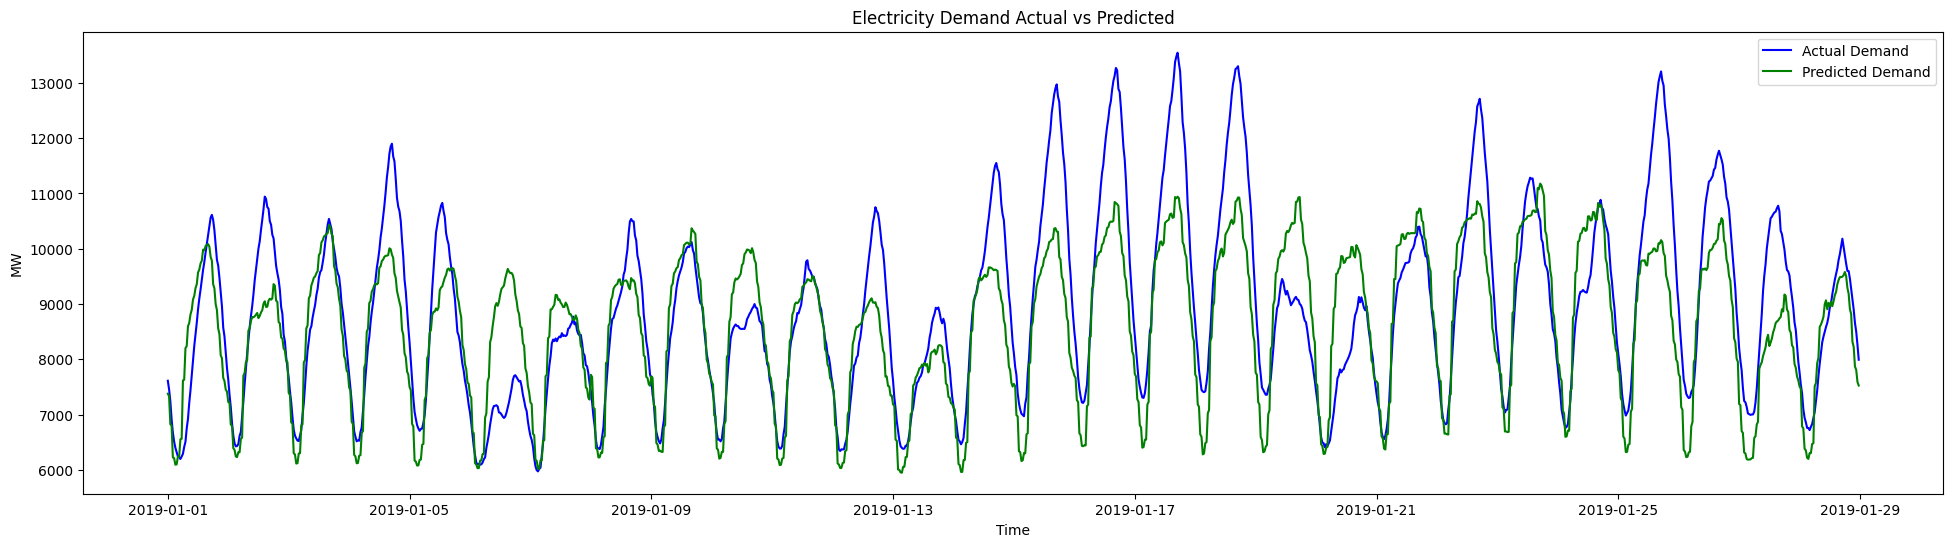

In [81]:
plt.figure(figsize=(24, 6))

plt.plot(results_week['datetime'], results_week['y'], label='Actual Demand', color='blue')
plt.plot(results_week['datetime'], results_week['y_pred'], label='Predicted Demand', color='green')
plt.title("Electricity Demand Actual vs Predicted")
plt.xlabel('Time')
plt.ylabel('MW')

plt.legend()
plt.show()

In [33]:
eval_data = pd.read_csv('..//data//NSW//processed//cohort_overall_all.csv')
eval_data = pd.read_csv('..//data//NSW//processed//nsw_demand_features.csv')
eval_data = eval_data[eval_data['timestamp'] >= '2018-12-31 00:00:00+00:00']
eval_data = eval_data[['timestamp', 'y', 'y_forecast','is_hot_day']]
eval_data.head()

,timestamp,y,y_forecast,is_hot_day
157728,2018-12-31 00:00:00+00:00,7511.01,7605.26,1
157729,2018-12-31 00:30:00+00:00,7280.24,7353.70,1
157730,2018-12-31 01:00:00+00:00,7133.30,7100.28,1
157731,2018-12-31 01:30:00+00:00,6865.45,6898.50,1
157732,2018-12-31 02:00:00+00:00,6698.99,6677.36,1


In [83]:
print_metrics(eval_data['y'],eval_data['y_forecast'])

mse
4743.909825997165
rmse
68.87604682324012
mae
50.959888874564925
mape
0.6469145232437244
Bias
14.557545184994202


In [ ]:
eval_data = pd.merge(eval_data, results_data, on='timestamp', how='left')
eval_data = eval_data.dropna()
eval_data[['datetime','is_hot_day', 'y_x', 'TCN_all_pred', 'TCN_day_pred']]

,timestamp,y_x,y_forecast,is_hot_day,y_y,TCN_day_pred,datetime,TCN_all_pred
48,2019-01-01 00:00:00+00:00,7612.74,7662.71,1,7612.74,7122.552660,2019-01-01 00:00:00+00:00,7792.934411
49,2019-01-01 00:30:00+00:00,7457.58,7445.34,1,7457.58,7062.697875,2019-01-01 00:30:00+00:00,7583.711282
50,2019-01-01 01:00:00+00:00,7243.21,7244.05,1,7243.21,6754.457212,2019-01-01 01:00:00+00:00,7181.560727
51,2019-01-01 01:30:00+00:00,6918.55,6992.60,1,6918.55,6687.281109,2019-01-01 01:30:00+00:00,7000.301095
52,2019-01-01 02:00:00+00:00,6676.58,6700.60,1,6676.58,6260.067964,2019-01-01 02:00:00+00:00,6728.822967
...,...,...,...,...,...,...,...,...
38779,2021-03-17 21:30:00+00:00,7503.12,7518.59,0,7503.12,7674.118583,2021-03-17 21:30:00+00:00,7606.382581
38780,2021-03-17 22:00:00+00:00,7419.77,7409.33,0,7419.77,7419.204423,2021-03-17 22:00:00+00:00,7516.552034
38781,2021-03-17 22:30:00+00:00,7417.91,7422.63,0,7417.91,7316.086016,2021-03-17 22:30:00+00:00,7451.073757
38782,2021-03-17 23:00:00+00:00,7287.32,7313.13,0,7287.32,7289.721481,2021-03-17 23:00:00+00:00,7373.956156


In [37]:
eval_data = eval_data[['datetime','is_hot_day', 'y_x', 'TCN_all_pred', 'TCN_day_pred']].rename(columns={'datetime':'timestamp', 'y_x': 'y'})
eval_data

,timestamp,is_hot_day,y,TCN_all_pred,TCN_day_pred
48,2019-01-01 00:00:00+00:00,1,7612.74,7792.934411,7122.552660
49,2019-01-01 00:30:00+00:00,1,7457.58,7583.711282,7062.697875
50,2019-01-01 01:00:00+00:00,1,7243.21,7181.560727,6754.457212
51,2019-01-01 01:30:00+00:00,1,6918.55,7000.301095,6687.281109
52,2019-01-01 02:00:00+00:00,1,6676.58,6728.822967,6260.067964
...,...,...,...,...,...
38779,2021-03-17 21:30:00+00:00,0,7503.12,7606.382581,7674.118583
38780,2021-03-17 22:00:00+00:00,0,7419.77,7516.552034,7419.204423
38781,2021-03-17 22:30:00+00:00,0,7417.91,7451.073757,7316.086016
38782,2021-03-17 23:00:00+00:00,0,7287.32,7373.956156,7289.721481


In [38]:
eval_hot = eval_data[eval_data['is_hot_day']==1]
eval_hot

,timestamp,is_hot_day,y,TCN_all_pred,TCN_day_pred
48,2019-01-01 00:00:00+00:00,1,7612.74,7792.934411,7122.552660
49,2019-01-01 00:30:00+00:00,1,7457.58,7583.711282,7062.697875
50,2019-01-01 01:00:00+00:00,1,7243.21,7181.560727,6754.457212
51,2019-01-01 01:30:00+00:00,1,6918.55,7000.301095,6687.281109
52,2019-01-01 02:00:00+00:00,1,6676.58,6728.822967,6260.067964
...,...,...,...,...,...
38587,2021-03-13 21:30:00+00:00,1,8257.63,7487.179512,7380.057821
38588,2021-03-13 22:00:00+00:00,1,8116.97,7400.346611,7205.755354
38589,2021-03-13 22:30:00+00:00,1,7997.84,7293.150277,7178.024002
38590,2021-03-13 23:00:00+00:00,1,7709.37,7192.926829,7076.211224


In [41]:
print_metrics(eval_data['y'],eval_data['TCN_all_pred'])
print_metrics(eval_data['y'],eval_data['TCN_day_pred'])

mse
265014.5222986852
rmse
514.7956121595106
mae
334.21472378652317
mape
4.169412924715272
Bias
-5.996194847452378
mse
441190.1603626612
rmse
664.2214693629386
mae
476.7925136430979
mape
6.046567006220722
Bias
4.753387244520509


In [42]:
print_metrics(eval_hot['y'],eval_hot['TCN_all_pred'])
print_metrics(eval_hot['y'],eval_hot['TCN_day_pred'])

mse
801690.6544935519
rmse
895.371796793685
mae
619.8774785766096
mape
6.590790534117405
Bias
-468.7597030823437
mse
1141150.7138568866
rmse
1068.246560423616
mae
762.4619357162768
mape
8.149975199616502
Bias
-565.6328362385735


In [3]:
cohort_eval_data = pd.read_csv('..//data//NSW//processed//cohort3_overall_all.csv')
cohort_eval_data

,timestamp,is_hot_day,true,op_latest,op_24h,op_24h_latest
0,2019-01-01 00:00:00,1,7612.74,7662.71,7734.27,7734.27
1,2019-01-01 00:30:00,1,7457.58,7445.34,7471.96,7471.96
2,2019-01-01 01:00:00,1,7243.21,7244.05,7204.11,7204.11
3,2019-01-01 01:30:00,1,6918.55,6992.60,6854.39,6854.39
4,2019-01-01 02:00:00,1,6676.58,6700.60,6598.30,6598.30
...,...,...,...,...,...,...
38731,2021-03-17 21:30:00,0,7503.12,7518.59,7364.36,7364.36
38732,2021-03-17 22:00:00,0,7419.77,7409.33,7284.49,7284.49
38733,2021-03-17 22:30:00,0,7417.91,7422.63,7240.18,7240.18
38734,2021-03-17 23:00:00,0,7287.32,7313.13,7145.45,7145.45


In [5]:
print_metrics(cohort_eval_data['true'],cohort_eval_data['op_latest'])

mse
4746.328743344694
rmse
68.8936045169992
mae
50.96885429574557
mape
0.6470586904834982
Bias
14.560438351920697


In [45]:
eval_data["slot"] = eval_data["timestamp"].dt.hour * 2 + (eval_data["timestamp"].dt.minute // 30)
eval_data.to_csv("TCN_pred.csv",index=False)
eval_data

,timestamp,is_hot_day,y,TCN_all_pred,TCN_day_pred,slot
48,2019-01-01 00:00:00+00:00,1,7612.74,7792.934411,7122.552660,0
49,2019-01-01 00:30:00+00:00,1,7457.58,7583.711282,7062.697875,1
50,2019-01-01 01:00:00+00:00,1,7243.21,7181.560727,6754.457212,2
51,2019-01-01 01:30:00+00:00,1,6918.55,7000.301095,6687.281109,3
52,2019-01-01 02:00:00+00:00,1,6676.58,6728.822967,6260.067964,4
...,...,...,...,...,...,...
38779,2021-03-17 21:30:00+00:00,0,7503.12,7606.382581,7674.118583,43
38780,2021-03-17 22:00:00+00:00,0,7419.77,7516.552034,7419.204423,44
38781,2021-03-17 22:30:00+00:00,0,7417.91,7451.073757,7316.086016,45
38782,2021-03-17 23:00:00+00:00,0,7287.32,7373.956156,7289.721481,46


In [44]:
eval_hot["slot"] = eval_hot["timestamp"].dt.hour * 2 + (eval_hot["timestamp"].dt.minute // 30)
eval_hot

/tmp/ipykernel_47023/946321961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eval_hot["slot"] = eval_hot["timestamp"].dt.hour * 2 + (eval_hot["timestamp"].dt.minute // 30)


,timestamp,is_hot_day,y,TCN_all_pred,TCN_day_pred,slot
48,2019-01-01 00:00:00+00:00,1,7612.74,7792.934411,7122.552660,0
49,2019-01-01 00:30:00+00:00,1,7457.58,7583.711282,7062.697875,1
50,2019-01-01 01:00:00+00:00,1,7243.21,7181.560727,6754.457212,2
51,2019-01-01 01:30:00+00:00,1,6918.55,7000.301095,6687.281109,3
52,2019-01-01 02:00:00+00:00,1,6676.58,6728.822967,6260.067964,4
...,...,...,...,...,...,...
38587,2021-03-13 21:30:00+00:00,1,8257.63,7487.179512,7380.057821,43
38588,2021-03-13 22:00:00+00:00,1,8116.97,7400.346611,7205.755354,44
38589,2021-03-13 22:30:00+00:00,1,7997.84,7293.150277,7178.024002,45
38590,2021-03-13 23:00:00+00:00,1,7709.37,7192.926829,7076.211224,46


In [57]:
def mae(y, yp):
    return np.mean(np.abs(yp - y))

def rmse(y, yp):
    e = yp - y
    return np.sqrt(np.mean(e * e))

def mape(y, yp):
    denom = np.where(y == 0, np.nan, np.abs(y))
    return np.nanmean(np.abs(yp - y) / denom) * 100

def bias(y, yp):
    return np.mean(yp - y)

def by_hour_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for slot, g in df.groupby("slot"):
        y, yp = g["y"].to_numpy(), g["TCN_all_pred"].to_numpy()
        rows.append({
            "slot": int(slot),
            "MAE_MW": mae(y, yp),
            "RMSE_MW": rmse(y, yp),
            "MAPE_%": mape(y, yp),
            "Bias_MW": bias(y, yp),
            "n": len(g)
        })
    return pd.DataFrame(rows).sort_values("slot").reset_index(drop=True)

eval_slots_all = by_hour_metrics(eval_data)
eval_slots_all_hot = by_hour_metrics(eval_hot)

def by_hour_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for slot, g in df.groupby("slot"):
        y, yp = g["y"].to_numpy(), g["TCN_day_pred"].to_numpy()
        rows.append({
            "slot": int(slot),
            "MAE_MW": mae(y, yp),
            "RMSE_MW": rmse(y, yp),
            "MAPE_%": mape(y, yp),
            "Bias_MW": bias(y, yp),
            "n": len(g)
        })
    return pd.DataFrame(rows).sort_values("slot").reset_index(drop=True)

eval_slots_day = by_hour_metrics(eval_data)
eval_slots_day_hot = by_hour_metrics(eval_hot)


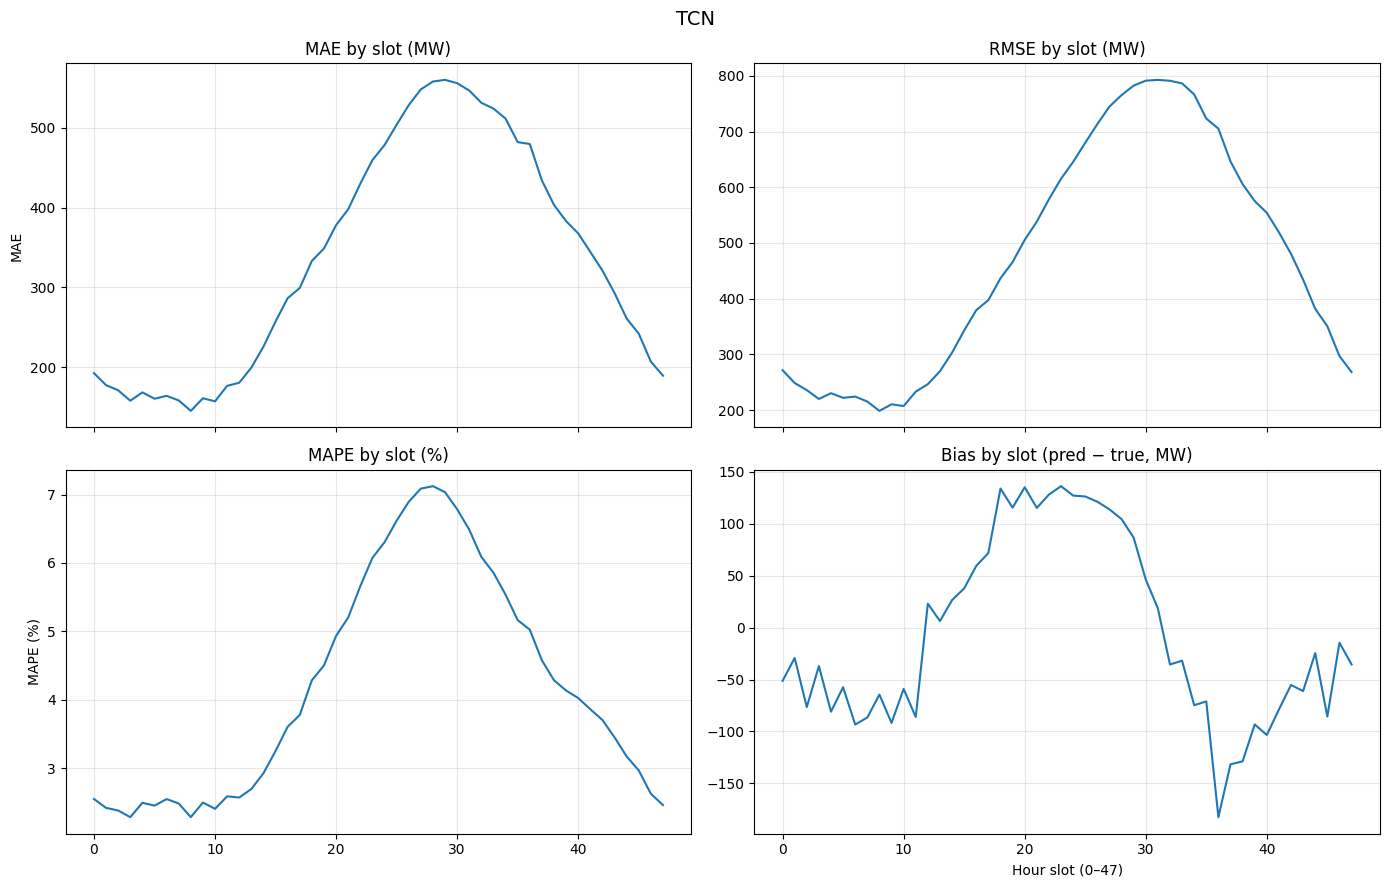

In [47]:
def plot_by_slot(per_h: pd.DataFrame, title: str):
    fig, axs = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    s = per_h["slot"].to_numpy()
    axs = axs.ravel()

    axs[0].plot(s, per_h["MAE_MW"]);   axs[0].set_title("MAE by slot (MW)");   axs[0].set_ylabel("MAE")
    axs[1].plot(s, per_h["RMSE_MW"]);  axs[1].set_title("RMSE by slot (MW)")
    axs[2].plot(s, per_h["MAPE_%"]);   axs[2].set_title("MAPE by slot (%)");   axs[2].set_ylabel("MAPE (%)")
    axs[3].plot(s, per_h["Bias_MW"]);  axs[3].set_title("Bias by slot (pred − true, MW)"); axs[3].set_xlabel("Hour slot (0–47)")

    for ax in axs: ax.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()
    
plot_by_slot(eval_slots_all, "TCN")

In [59]:
eval_slots_day

,slot,MAE_MW,RMSE_MW,MAPE_%,Bias_MW,n
0,0,364.662669,454.449662,4.722610,-340.751911,807
1,1,263.462932,347.631682,3.494875,-200.348996,807
2,2,310.273749,400.616199,4.185975,-291.766504,807
3,3,234.679147,306.187927,3.301606,-112.106488,807
4,4,345.974287,431.484980,4.963072,-328.434386,807
5,5,228.436646,308.934983,3.389185,-176.262649,807
6,6,234.913895,315.617084,3.537427,-179.243563,807
7,7,199.246652,272.958252,3.060157,-125.698672,807
8,8,204.906592,274.846795,3.154142,-118.569907,807
9,9,257.152424,321.795435,3.911738,-202.540864,807


In [52]:
def plot_by_slot_compare(per_h_a: pd.DataFrame, label_a: str,
                         per_h_b: pd.DataFrame, label_b: str,
                         per_h_c: pd.DataFrame, label_c: str,
                         per_h_d: pd.DataFrame, label_d: str,
                         title: str):

    # Expect columns: ["slot","MAE_MW","RMSE_MW","MAPE_%","Bias_MW"]
    fig, axs = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axs = axs.ravel()
    s_a = per_h_a["slot"].to_numpy()
    s_b = per_h_b["slot"].to_numpy()
    s_c = per_h_c["slot"].to_numpy()
    s_d = per_h_d["slot"].to_numpy()

    def draw(ax, col, yl):
        ax.plot(s_a, per_h_a[col].to_numpy(), label=label_a, lw=1.6)
        ax.plot(s_b, per_h_b[col].to_numpy(), label=label_b, lw=1.6)
        ax.plot(s_c, per_h_c[col].to_numpy(), label=label_c, lw=1.6)
        ax.plot(s_d, per_h_d[col].to_numpy(), label=label_d, lw=1.6)
        ax.set_ylabel(yl); ax.grid(True, alpha=0.3); ax.legend()

    draw(axs[0], "MAE_MW",  "MAE (MW)")
    axs[0].set_title("MAE by Horizon (MW)")
    draw(axs[1], "RMSE_MW", "RMSE (MW)")
    axs[1].set_title("RMSE by Horizon (MW)")
    draw(axs[2], "MAPE_%",  "MAPE (%)")
    axs[2].set_title("MAPE by Horizon (%)")
    draw(axs[3], "Bias_MW", "Bias (MW)")
    axs[3].set_title("Bias by Horizon (pred − true, MW)")
    axs[3].set_xlabel("Horizon (slots ahead)")
    for ax in axs[:3]: ax.set_xlabel("")  # top row no x label

    fig.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

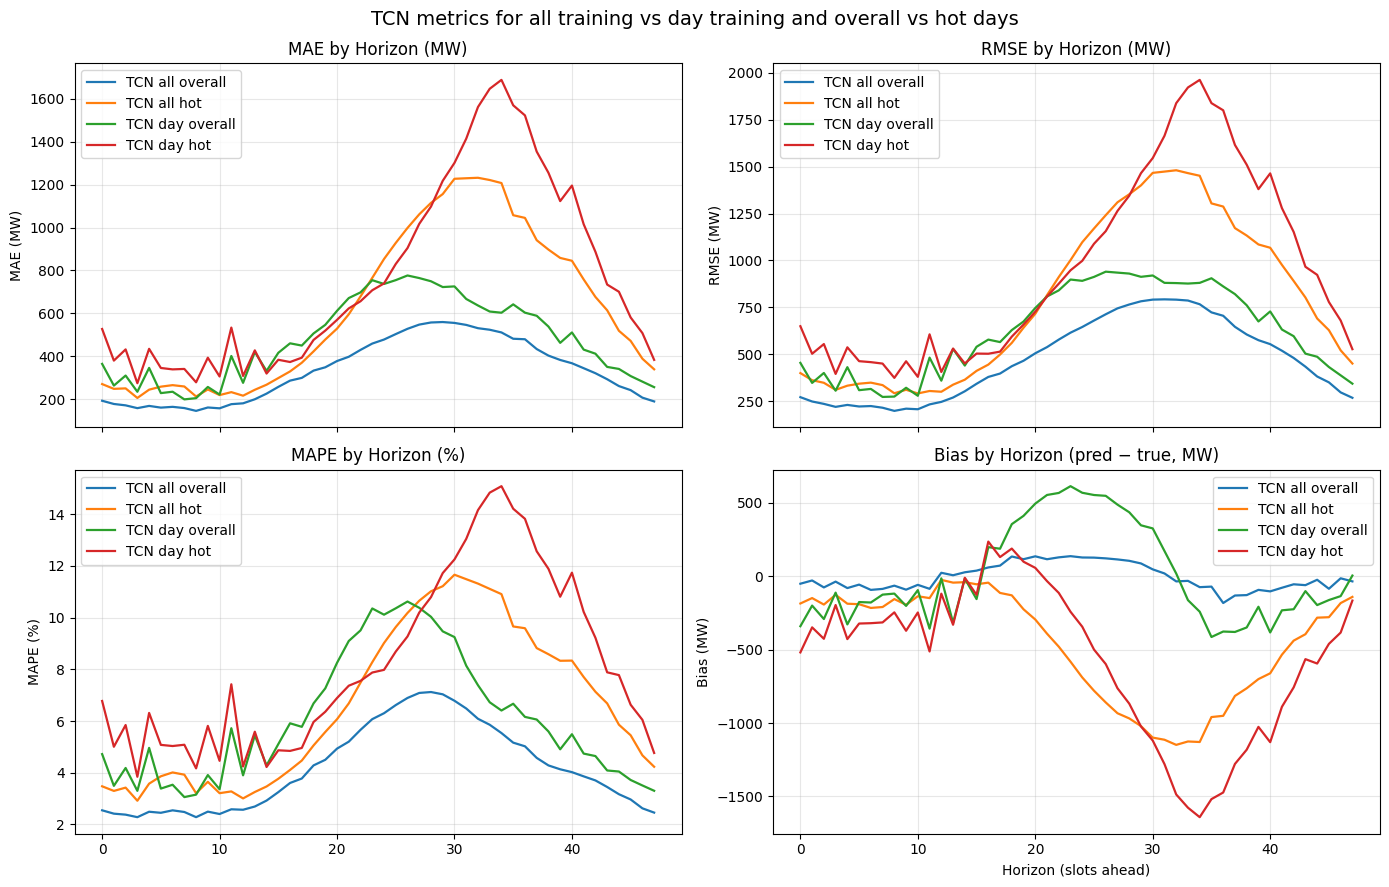

In [60]:
plot_by_slot_compare(eval_slots_all,"TCN all overall", eval_slots_all_hot,"TCN all hot",eval_slots_day,"TCN day overall",eval_slots_day_hot,"TCN day hot", "TCN metrics for all training vs day training and overall vs hot days")